In [1]:
!pip install PyGRF

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 48.8 MB/s  0:00:00
  Created wheel for PyGRF: filename=pygrf-0.0.12-py3-none-any.whl size=8194 sha256=e9ced1988edf20c6b50d24d2cff09cddafcc19009164ab38a882374b51dbbf1c
  Stored in directory: /home/jovyan/.cache/pip/wheels/73/36/1e/c7613f44ee5c524ff55c7c7f55553c71c603cc93592daa0168
Successfully built PyGRF
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [PyGRF]32m3/5 [esda]sal]


In [2]:
# Import libraries.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from shapely.geometry import box

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

from PyGRF import PyGRF

# Hide the warnings printed by each of the ~9,500 local forests.
warnings.filterwarnings("ignore")

## 1. Load the sample data

Samples made only of coarse fragments (`esqueleto` = 1000 g/kg) are removed, because their sand value of 0 is not a real measurement.

In [3]:
# Input data and outputs are kept in separate folders next to this notebook.
INPUT_DIR = Path("input")
OUTPUT_DIR = Path("output")

# Define the sample-data path.
samples_path = INPUT_DIR / "c3_soildata_psd_modeling_0_50cm.gpkg"

# Read sample points.
samples = gpd.read_file(samples_path)

# Drop layers made only of coarse fragments (esqueleto = 1000 g/kg).
# They contain no fine earth, so sand = 0 there is not a measurement.
samples = samples[samples["esqueleto"] < 1000].reset_index(drop=True)
print("Samples after removing esqueleto = 1000:", len(samples))

samples.info()
display(samples.head())
display(samples.describe(include="all"))

Samples after removing esqueleto = 1000: 14165
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14165 entries, 0 to 14164
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   id                        14165 non-null  object  
 1   longitude                 14165 non-null  float64 
 2   latitude                  14165 non-null  float64 
 3   profundidade              14165 non-null  float64 
 4   esqueleto                 14165 non-null  int32   
 5   areia                     14165 non-null  int32   
 6   silte                     14165 non-null  int32   
 7   argila                    14165 non-null  int32   
 8   log_silte1p_argila1p      14165 non-null  float64 
 9   log_areia1p_argila1p      14165 non-null  float64 
 10  log_esqueleto1p_argila1p  14165 non-null  float64 
 11  geometry                  14165 non-null  geometry
dtypes: float64(6), geometry(1), int32(4), object(1)

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,-6.478510,POINT (-35.13416 -8.57683)
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,-6.447306,POINT (-50.23177 -29.47568)
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,-6.655440,POINT (-64.05944 -11.77)
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,-6.608001,POINT (-64.33028 -12.01833)
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,-0.004975,POINT (-63.94167 -9.89167)


,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
count,14165,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165
unique,14057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14165
top,ctb0765-GWDSM-4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-60.88583332999999 -12.717777780000006)
freq,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,-53.621213,-16.082803,24.697653,64.939287,484.000424,182.003318,333.996258,-0.627611,0.498344,-3.082999,NaN
std,NaN,8.079586,8.481977,14.933753,110.124817,277.086129,140.243171,215.486282,0.918257,1.954324,2.578236,NaN
min,NaN,-73.850000,-33.686969,0.500000,0.000000,0.000000,0.000000,0.000000,-6.673298,-6.792344,-6.888572,NaN
25%,NaN,-61.150000,-22.501390,10.000000,0.000000,249.000000,77.000000,150.000000,-1.252763,-0.660357,-5.564520,NaN
50%,NaN,-54.150000,-15.936090,22.500000,10.000000,483.000000,144.000000,300.000000,-0.707513,0.423050,-3.209306,NaN
75%,NaN,-47.316670,-9.900021,39.000000,118.000000,710.000000,260.000000,492.000000,0.000000,1.474801,-0.796944,NaN


## 2. Load the raster predictors

Every GeoTIFF in the `input` folder is used as a predictor, and its file name becomes the variable name.

In [4]:
# Define the predictor directory.
workdir_xvars = INPUT_DIR

# List GeoTIFF predictors.
raster_files = sorted(workdir_xvars.glob("*.tif"))

print(f"Number of raster predictors: {len(raster_files)}")
for f in raster_files:
    print(f.name)

Number of raster predictors: 25
HAND.tif
Mean_curvature.tif
NTSI.tif
TPI_11x11.tif
bio1.tif
bio10.tif
bio11.tif
bio12.tif
bio13.tif
bio14.tif
bio15.tif
bio16.tif
bio17.tif
bio18.tif
bio19.tif
bio2.tif
bio3.tif
bio4.tif
bio5.tif
bio6.tif
bio7.tif
bio8.tif
bio9.tif
elevation.tif
slope.tif


In [5]:
# Use file stems as predictor names.
raster_names = [f.stem for f in raster_files]

raster_names

['HAND',
 'Mean_curvature',
 'NTSI',
 'TPI_11x11',
 'bio1',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'elevation',
 'slope']

## 3. Extract raster values at sample locations

The samples must be in geographic coordinates (degrees), because the spatial blocks are defined as 2° × 2° cells.

In [6]:
# Check sample and raster CRS.
with rasterio.open(raster_files[0]) as src:
    raster_crs = src.crs

print("Sample CRS:", samples.crs)
print("Raster CRS:", raster_crs)

# Match the raster CRS.
if samples.crs != raster_crs:
    samples = samples.to_crs(raster_crs)

# Spatial blocks are defined in degrees.
if not samples.crs.is_geographic:
    raise ValueError(
        "The sample CRS must be geographic to create 2° x 2° blocks."
    )

Sample CRS: EPSG:4326
Raster CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


ERROR 1: PROJ: internal_proj_identify: /opt/conda/envs/geospatial/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.


In [7]:
# Extract raster values at sample locations.
coords = [(geom.x, geom.y) for geom in samples.geometry]

for raster_path, raster_name in zip(raster_files, raster_names):
    with rasterio.open(raster_path) as src:
        values = [v[0] for v in src.sample(coords)]

        if src.nodata is not None:
            values = [
                np.nan if v == src.nodata else v
                for v in values
            ]

        samples[raster_name] = values

display(samples.head())

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


## 4. Prepare the modeling dataset

Only the response and the raster predictors are kept, and incomplete samples are removed. A second table (`samples_model`) keeps the geometry of the same samples, aligned row by row, because it is needed to build the spatial blocks.

In [8]:
# Remove non-predictor variables.
columns_to_remove = [
    "id",
    "longitude",
    "latitude",
    "profundidade",
    "esqueleto",
    "silte",
    "argila",
    "log_silte1p_argila1p",
    "log_areia1p_argila1p",
    "log_esqueleto1p_argila1p",
]

samples_df = samples.drop(columns="geometry").copy()

samples_df = samples_df.drop(
    columns=[c for c in columns_to_remove if c in samples_df.columns]
)

print("Number of samples before removing NA:", len(samples_df))

# Keep complete observations only.
complete_idx = samples_df.notna().all(axis=1)

samples_df = samples_df.loc[complete_idx].copy()
samples_model = samples.loc[complete_idx].copy()

# Reset indices to keep all objects aligned.
samples_df = samples_df.reset_index(drop=True)
samples_model = samples_model.reset_index(drop=True)

print("Number of complete samples:", len(samples_df))

display(samples_df.head())
display(samples_df.describe())

Number of samples before removing NA: 14165
Number of complete samples: 13635


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,200,29.005001,-4.573328e-06,0.000083,-6.528925,24.391666,25.516666,22.983334,2119.0,328.0,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,120,773.000000,9.522858e-06,-0.001479,173.289261,14.950000,18.783333,11.350000,1997.0,191.0,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,157,0.000000,-8.854991e-06,0.005365,-16.669422,25.970833,26.666666,24.983334,1583.0,253.0,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,60,0.000000,-2.143425e-07,0.003746,-11.256198,26.200001,26.950001,25.200001,1555.0,251.0,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,260,38.011002,-8.406725e-06,-0.003907,-0.975207,25.712500,26.283335,24.966667,2036.0,320.0,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
count,13635.000000,13635.000000,1.363500e+04,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,...,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000,13635.000000
mean,470.799413,109.081757,2.926289e-07,0.001952,1.766811,22.961235,24.806932,20.749537,1645.891113,253.690506,...,11.321218,66.242760,170.191254,31.237925,13.846916,17.391008,23.347429,21.724739,361.743601,1.190882
std,269.032825,152.350693,2.452227e-05,0.009557,44.263935,3.127032,2.088972,4.399393,394.773499,69.603615,...,1.385312,8.933206,118.879616,2.452920,4.310641,2.904938,3.429467,4.011034,311.832080,1.563568
min,0.000000,0.000000,-1.851026e-04,-0.064239,-389.107452,9.283334,11.466667,6.766666,379.000000,64.000000,...,6.216667,40.659340,23.880211,16.600000,-1.300000,9.099998,10.933333,6.766666,1.000000,0.000000
25%,240.000000,20.000000,-7.098722e-06,-0.001158,-13.157024,20.045834,23.700001,16.791666,1457.000000,190.000000,...,10.475000,61.070642,64.436661,30.200001,9.900000,15.900000,22.266666,18.825001,132.000000,0.323985
50%,471.000000,50.001999,-1.633708e-09,0.001107,-0.413223,24.004168,25.200001,22.416666,1634.000000,262.000000,...,11.500000,68.404625,156.166199,31.700001,14.600000,18.100000,24.733334,22.850000,244.000000,0.688674
75%,690.000000,136.003494,8.104492e-06,0.002972,14.280992,25.368750,26.283333,24.466667,1852.500000,311.000000,...,12.441667,71.421837,235.627792,33.200001,17.000000,19.100002,25.666666,24.783333,530.000000,1.368095
max,1000.000000,2046.005981,2.857003e-04,0.157383,591.388428,28.066666,29.533333,27.266666,3624.000000,585.000000,...,15.208334,90.591385,461.137207,36.400002,22.900000,24.200001,28.199999,28.466667,2666.000000,17.405693


In [9]:
# Convert sand content to percent.
samples_df["areia"] = samples_df["areia"] / 10

# Add a permanent observation ID.
samples_model["obs_id"] = np.arange(len(samples_model))

## 5. Create the spatial blocks

The strategy follows the R reference implementation used in the course:

- fixed 2° × 2° geographic blocks;
- complete blocks assigned to training or independent test;
- about 30 % of observations reserved for the spatial test;
- training blocks assigned to 10 spatial folds;
- complete blocks remain together within each fold.

Each sample receives the identifier of the block that contains it.

In [10]:
# ============================================================
# CREATE SPATIAL BLOCKS
# ============================================================

block_size = 2.0

# Extract point coordinates.
samples_model["longitude_cv"] = samples_model.geometry.x
samples_model["latitude_cv"] = samples_model.geometry.y

# Anchor the grid at a multiple of 2 degrees.
origin_lon = (
    np.floor(samples_model["longitude_cv"].min() / block_size)
    * block_size
)
origin_lat = (
    np.floor(samples_model["latitude_cv"].min() / block_size)
    * block_size
)

# Assign each sample to one block.
samples_model["block_col"] = np.floor(
    (samples_model["longitude_cv"] - origin_lon) / block_size
).astype(int)

samples_model["block_row"] = np.floor(
    (samples_model["latitude_cv"] - origin_lat) / block_size
).astype(int)

samples_model["block_id"] = (
    "B_"
    + samples_model["block_col"].astype(str)
    + "_"
    + samples_model["block_row"].astype(str)
)

print("Grid origin:", origin_lon, origin_lat)
print("Total samples:", len(samples_model))
print("Occupied spatial blocks:", samples_model["block_id"].nunique())

Grid origin: -74.0 -34.0
Total samples: 13635
Occupied spatial blocks: 198


In [11]:
# Create occupied block polygons.
block_index = (
    samples_model[
        ["block_id", "block_col", "block_row"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

block_index["geometry"] = [
    box(
        origin_lon + col * block_size,
        origin_lat + row * block_size,
        origin_lon + (col + 1) * block_size,
        origin_lat + (row + 1) * block_size,
    )
    for col, row in zip(
        block_index["block_col"],
        block_index["block_row"]
    )
]

blocks_gdf = gpd.GeoDataFrame(
    block_index,
    geometry="geometry",
    crs=samples_model.crs
)

## 6. Create spatial training and independent test sets

Blocks are shuffled and added to the test set until it holds about 30 % of the samples. At least 10 blocks are kept for training so that 10 folds can be formed. A check confirms that no block appears in both sets.

In [12]:
# ============================================================
# SPATIAL TRAIN / TEST SPLIT
# ============================================================

test_fraction = 0.30
k_folds = 10
random_state = 123

# Count samples per block.
block_counts = (
    samples_model.groupby("block_id")
    .size()
    .reset_index(name="n")
)

if len(block_counts) <= k_folds:
    raise ValueError(
        f"At least {k_folds + 1} occupied blocks are required."
    )

# Randomize block order reproducibly.
rng_split = np.random.RandomState(random_state)
block_counts = block_counts.iloc[
    rng_split.permutation(len(block_counts))
].reset_index(drop=True)

target_n_test = round(len(samples_model) * test_fraction)

# Keep at least k blocks for spatial CV.
max_test_blocks = len(block_counts) - k_folds
cum_test = block_counts["n"].cumsum().to_numpy()

best_cut = (
    np.argmin(
        np.abs(
            cum_test[:max_test_blocks] - target_n_test
        )
    )
    + 1
)

test_blocks = set(
    block_counts.loc[: best_cut - 1, "block_id"]
)
train_blocks = set(block_counts["block_id"]) - test_blocks

# Check train/test block overlap.
if train_blocks & test_blocks:
    raise RuntimeError(
        "Spatial leakage detected between training and test blocks."
    )

samples_model["dataset"] = np.where(
    samples_model["block_id"].isin(test_blocks),
    "Independent test",
    "Training"
)

print(samples_model["dataset"].value_counts())
print("Training blocks:", len(train_blocks))
print("Test blocks:", len(test_blocks))
print(
    "Actual test proportion:",
    round(
        (samples_model["dataset"] == "Independent test").mean(),
        3
    )
)

dataset
Training            9454
Independent test    4181
Name: count, dtype: int64
Training blocks: 138
Test blocks: 60
Actual test proportion: 0.307


## 7. Assign training blocks to 10 spatial folds

Blocks contain very different numbers of samples. To obtain folds of similar size, blocks are sorted from largest to smallest and each one is assigned to the fold that currently has the fewest samples (ties are broken at random).

In [12]:
# ============================================================
# ASSIGN BLOCKS TO FOLDS
# ============================================================

train_block_counts = (
    samples_model.loc[
        samples_model["dataset"] == "Training"
    ]
    .groupby("block_id")
    .size()
    .reset_index(name="n")
)

if len(train_block_counts) < k_folds:
    raise ValueError(
        f"Only {len(train_block_counts)} training blocks are available "
        f"for {k_folds} folds."
    )

# Use random values only to break ties reproducibly.
rng_folds = np.random.RandomState(random_state)
train_block_counts["random_order"] = rng_folds.uniform(
    size=len(train_block_counts)
)

# Allocate larger blocks first.
train_block_counts = (
    train_block_counts
    .sort_values(
        ["n", "random_order"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

fold_sizes = np.zeros(k_folds, dtype=int)
fold_assignment = []

for n_samples in train_block_counts["n"]:
    candidate_folds = np.flatnonzero(
        fold_sizes == fold_sizes.min()
    )

    selected_fold = rng_folds.choice(candidate_folds)

    fold_assignment.append(selected_fold + 1)
    fold_sizes[selected_fold] += n_samples

train_block_counts["fold"] = fold_assignment

# Attach folds to training samples.
fold_lookup = dict(
    zip(
        train_block_counts["block_id"],
        train_block_counts["fold"]
    )
)

samples_model["fold"] = samples_model["block_id"].map(
    fold_lookup
)

# Test samples intentionally have no fold.
samples_model.loc[
    samples_model["dataset"] == "Independent test",
    "fold"
] = np.nan

## 8. Diagnose and visualize the spatial folds

The table shows the number of samples and blocks used for training and validation in each fold. The maps show which blocks belong to each fold and to the independent test set.

Note that fold 1 is formed by a **single block** with about 1,000 samples (a densely sampled region): because the allocation balances the number of *samples*, the largest block fills one fold on its own, while the other folds combine 11–17 smaller blocks.

In [13]:
# Summarize spatial folds.
fold_observations = (
    samples_model.loc[
        samples_model["dataset"] == "Training"
    ]
    .groupby("fold")
    .size()
    .rename("Validation samples")
)

fold_blocks = (
    samples_model.loc[
        samples_model["dataset"] == "Training"
    ]
    .groupby("fold")["block_id"]
    .nunique()
    .rename("Validation blocks")
)

n_train_samples = (
    samples_model["dataset"] == "Training"
).sum()

n_train_blocks = len(train_blocks)

fold_summary = pd.concat(
    [fold_observations, fold_blocks],
    axis=1
).reset_index()

fold_summary["Training samples"] = (
    n_train_samples - fold_summary["Validation samples"]
)

fold_summary["Training blocks"] = (
    n_train_blocks - fold_summary["Validation blocks"]
)

fold_summary = fold_summary[
    [
        "fold",
        "Training samples",
        "Validation samples",
        "Training blocks",
        "Validation blocks",
    ]
].rename(columns={"fold": "Fold"})

fold_summary["Fold"] = fold_summary["Fold"].astype(int)

print("Total samples:", len(samples_model))
print("Total occupied blocks:", samples_model["block_id"].nunique())
print("Number of folds:", k_folds)
display(fold_summary)

Total samples: 13636
Total occupied blocks: 198
Number of folds: 10


,Fold,Training samples,Validation samples,Training blocks,Validation blocks
0,1,8435,1020,137,1
1,2,8517,938,121,17
2,3,8517,938,121,17
3,4,8518,937,121,17
4,5,8518,937,121,17
5,6,8518,937,124,14
6,7,8519,936,123,15
7,8,8517,938,121,17
8,9,8518,937,126,12
9,10,8518,937,127,11


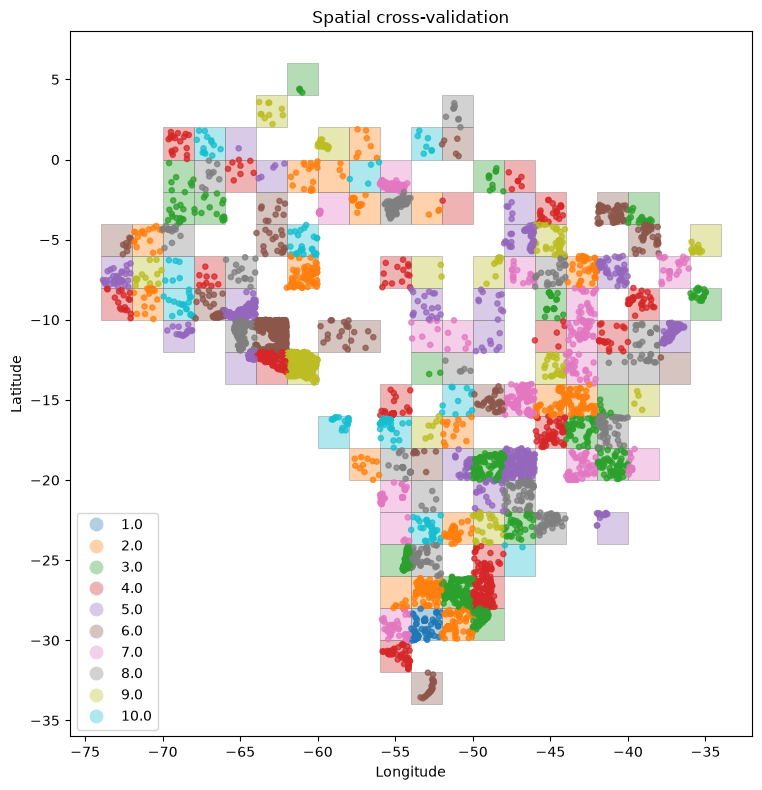

In [14]:
# Add fold information to block polygons.
block_info = (
    samples_model[
        ["block_id", "dataset", "fold"]
    ]
    .drop_duplicates("block_id")
)

blocks_plot = blocks_gdf.merge(
    block_info,
    on="block_id",
    how="left"
)

# Plot training folds.
fig, ax = plt.subplots(figsize=(10, 8))

training_blocks_plot = blocks_plot[
    blocks_plot["dataset"] == "Training"
].copy()

training_points_plot = samples_model[
    samples_model["dataset"] == "Training"
].copy()

training_blocks_plot.plot(
    ax=ax,
    column="fold",
    categorical=True,
    alpha=0.35,
    edgecolor="0.35",
    linewidth=0.6,
    legend=True,
)

training_points_plot.plot(
    ax=ax,
    column="fold",
    categorical=True,
    markersize=14,
    alpha=0.75,
)

ax.set_title("Spatial cross-validation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

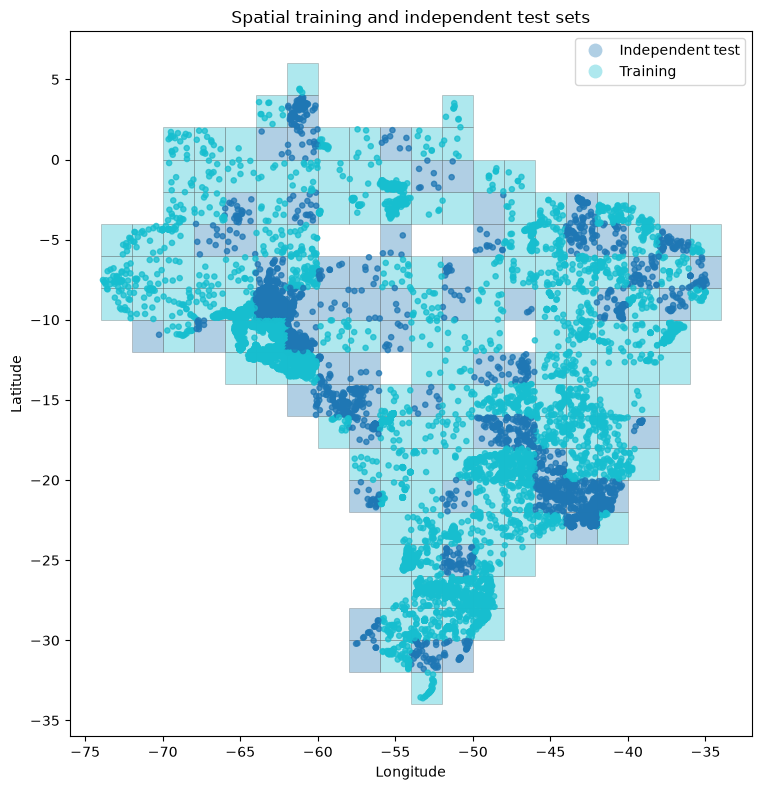

In [15]:
# Plot spatial training and test sets.
fig, ax = plt.subplots(figsize=(10, 8))

blocks_plot.plot(
    ax=ax,
    column="dataset",
    categorical=True,
    alpha=0.35,
    edgecolor="0.35",
    linewidth=0.6,
    legend=True,
)

samples_model.plot(
    ax=ax,
    column="dataset",
    categorical=True,
    markersize=14,
    alpha=0.75,
)

ax.set_title("Spatial training and independent test sets")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 9. Build explicit scikit-learn spatial CV indices

scikit-learn accepts a custom cross-validation as a list of `(train_indices, validation_indices)` pairs. We build this list from the fold of each training sample and check that no block is shared between the training and validation parts of any fold.

In [16]:
# Create response and predictor matrices.
X = samples_df.drop(columns="areia")
y = samples_df["areia"]

train_mask = (
    samples_model["dataset"] == "Training"
).to_numpy()

test_mask = (
    samples_model["dataset"] == "Independent test"
).to_numpy()

X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)

y_train = y.loc[train_mask].reset_index(drop=True)
y_test = y.loc[test_mask].reset_index(drop=True)

train_spatial = (
    samples_model.loc[train_mask]
    .reset_index(drop=True)
)

test_spatial = (
    samples_model.loc[test_mask]
    .reset_index(drop=True)
)

print("Training samples:", len(X_train))
print("Independent test samples:", len(X_test))

Training samples: 9455
Independent test samples: 4181


In [17]:
# ============================================================
# BUILD SCIKIT-LEARN SPATIAL CV INDICES
# ============================================================

training_fold_id = train_spatial["fold"].astype(int).to_numpy()

spatial_cv = []

for fold in range(1, k_folds + 1):
    validation_idx = np.flatnonzero(
        training_fold_id == fold
    )
    train_idx = np.flatnonzero(
        training_fold_id != fold
    )

    spatial_cv.append(
        (train_idx, validation_idx)
    )

# Check index sizes.
cv_index_summary = pd.DataFrame({
    "Fold": np.arange(1, k_folds + 1),
    "Training samples": [
        len(train_idx)
        for train_idx, _ in spatial_cv
    ],
    "Validation samples": [
        len(validation_idx)
        for _, validation_idx in spatial_cv
    ],
})

display(cv_index_summary)

,Fold,Training samples,Validation samples
0,1,8435,1020
1,2,8517,938
2,3,8517,938
3,4,8518,937
4,5,8518,937
5,6,8518,937
6,7,8519,936
7,8,8517,938
8,9,8518,937
9,10,8518,937


In [18]:
# Check block leakage within each fold.
for fold, (train_idx, validation_idx) in enumerate(
    spatial_cv,
    start=1
):
    train_blocks_fold = set(
        train_spatial.loc[train_idx, "block_id"]
    )
    validation_blocks_fold = set(
        train_spatial.loc[validation_idx, "block_id"]
    )

    overlap = train_blocks_fold & validation_blocks_fold

    if overlap:
        raise RuntimeError(
            f"Spatial leakage detected in Fold {fold}."
        )

print(
    "Spatial leakage check passed: "
    "no block is shared between training and validation."
)

Spatial leakage check passed: no block is shared between training and validation.


## 10. Define the classes

Sand content (%) is split into two classes at 50 %:

- **0**: sand < 50 %
- **1**: sand ≥ 50 % (sandy samples)

In [19]:
# Sand threshold (%) that separates the two classes.
sand_threshold = 50

y_train_class = (y_train >= sand_threshold).astype(int)
y_test_class = (y_test >= sand_threshold).astype(int)

class_names = [f"Sand < {sand_threshold} %", f"Sand ≥ {sand_threshold} %"]

display(pd.DataFrame({
    "Training": y_train_class.value_counts().sort_index(),
    "Independent test": y_test_class.value_counts().sort_index(),
}).rename(index=dict(enumerate(class_names))))

,Training,Independent test
areia,,
Sand < 50 %,4810,2409
Sand ≥ 50 %,4645,1772


## 11. How GRF works

A Geographical Random Forest is the machine-learning counterpart of GWR:

- it fits **one local Random Forest around each training sample**, using only its nearest neighbors (the **bandwidth**);
- it also fits one **global** Random Forest on all samples;
- the final prediction mixes both: $\hat p = w \cdot \hat p_{\text{local}} + (1 - w) \cdot \hat p_{\text{global}}$, where $w$ is the **local weight**.

**Classification with PyGRF.** PyGRF only implements regression forests. Trained on a 0/1 response, a regression forest predicts the **fraction of class 1** in each leaf, i.e. a **probability** of class 1 (a *probability forest*). A sample is assigned to class 1 when this probability is ≥ 0.5.

PyGRF needs coordinates in a projected CRS. We use SIRGAS 2000 / Brazil Polyconic (EPSG:5880), in kilometers.

In [20]:
# Projected coordinates (km) for PyGRF.
metric_crs = "EPSG:5880"

train_xy = train_spatial.to_crs(metric_crs).geometry
test_xy = test_spatial.to_crs(metric_crs).geometry

coords_train = pd.DataFrame({"x": train_xy.x / 1000, "y": train_xy.y / 1000})
coords_test = pd.DataFrame({"x": test_xy.x / 1000, "y": test_xy.y / 1000})

## 12. Choose the bandwidth and the local weight

PyGRF chooses both from the spatial autocorrelation of the response (incremental spatial autocorrelation, ISA):

- Moran's I of the classes is computed with $k$ nearest neighbors, for increasing $k$;
- the **bandwidth** is the $k$ with the most significant autocorrelation (highest z-score);
- the **local weight** is Moran's I at that $k$: the stronger the spatial structure, the more the local models are trusted.

In [21]:
# Search the bandwidth between 20 and 400 neighbors.
band_width, local_weight, p_value = PyGRF.search_bw_lw_ISA(
    y_train_class,
    coords_train,
    bw_min=20,
    bw_max=400,
    step=10
)

print(f"Bandwidth: {band_width} neighbors")
print(f"Local weight: {local_weight:.2f}")

bandwidth: 390, moran's I: 0.2707576052049009, p-value: 0.0
Bandwidth: 390 neighbors
Local weight: 0.27


## 13. Train the Geographical Random Forest

PyGRF trains one forest per training sample (about 9,500 forests), so this step can take around 30 minutes. For the same reason, the GRF is evaluated only on the independent spatial test: repeating it for each of the 10 spatial folds would take several hours.

In [22]:
# Define and train the GRF.
model_grf = PyGRF.PyGRFBuilder(
    band_width=band_width,
    n_estimators=50,
    max_features="sqrt",
    train_weighted=True,
    predict_weighted=True,
    resampled=True,
    random_state=123
)

model_grf.fit(X_train, y_train_class.astype(float), coords_train)

print("Local forests:", len(model_grf.local_models))

Local forests: 9455


## 14. Predict the independent spatial test data

PyGRF returns three probabilities of class 1:

- **Global RF**: the ordinary Random Forest trained on all samples;
- **Local RF**: the distance-weighted average of the nearby local forests;
- **GRF (combined)**: $w \cdot$ local $+ (1 - w) \cdot$ global.

In [23]:
# Predict unseen spatial blocks.
prob_combined, prob_global, prob_local = model_grf.predict(
    X_test,
    coords_test,
    local_weight=local_weight
)

probs = {
    "Global RF": np.asarray(prob_global),
    "Local RF": np.asarray(prob_local),
    "GRF (combined)": np.asarray(prob_combined),
}

# Class 1 when the probability is at least 0.5.
pred_class = {
    name: (prob >= 0.5).astype(int)
    for name, prob in probs.items()
}

## 15. Evaluate the independent spatial test

- **Accuracy**: fraction of correctly classified samples;
- **Balanced accuracy**: mean of the accuracy of each class (robust to unbalanced classes);
- **Kappa**: agreement beyond chance;
- **AUC**: how well the probabilities rank the two classes (independent of the 0.5 threshold).

In [24]:
# Calculate independent spatial-test metrics.
metrics_test = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test_class, pred_class[name]),
        "Balanced accuracy": balanced_accuracy_score(y_test_class, pred_class[name]),
        "Kappa": cohen_kappa_score(y_test_class, pred_class[name]),
        "AUC": roc_auc_score(y_test_class, probs[name]),
    }
    for name in probs
}).T

display(metrics_test)

,Accuracy,Balanced accuracy,Kappa,AUC
Global RF,0.618512,0.625227,0.242792,0.660525
Local RF,0.610619,0.609275,0.215147,0.635986
GRF (combined),0.625448,0.630202,0.253481,0.657751


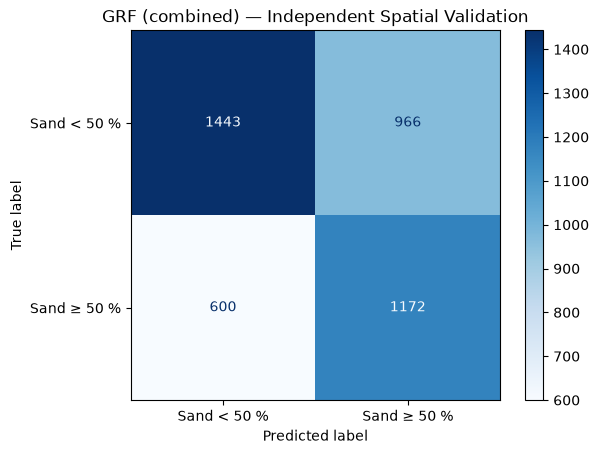

In [25]:
# Confusion matrix of the combined GRF.
ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    pred_class["GRF (combined)"],
    display_labels=class_names,
    cmap="Blues"
)
plt.title("GRF (combined) — Independent Spatial Validation")
plt.show()

## 16. Local feature importance

Besides predictions, GRF gives the **importance of each predictor at each training location** (from the local forests). The maps show the three predictors that are most important in the global model.

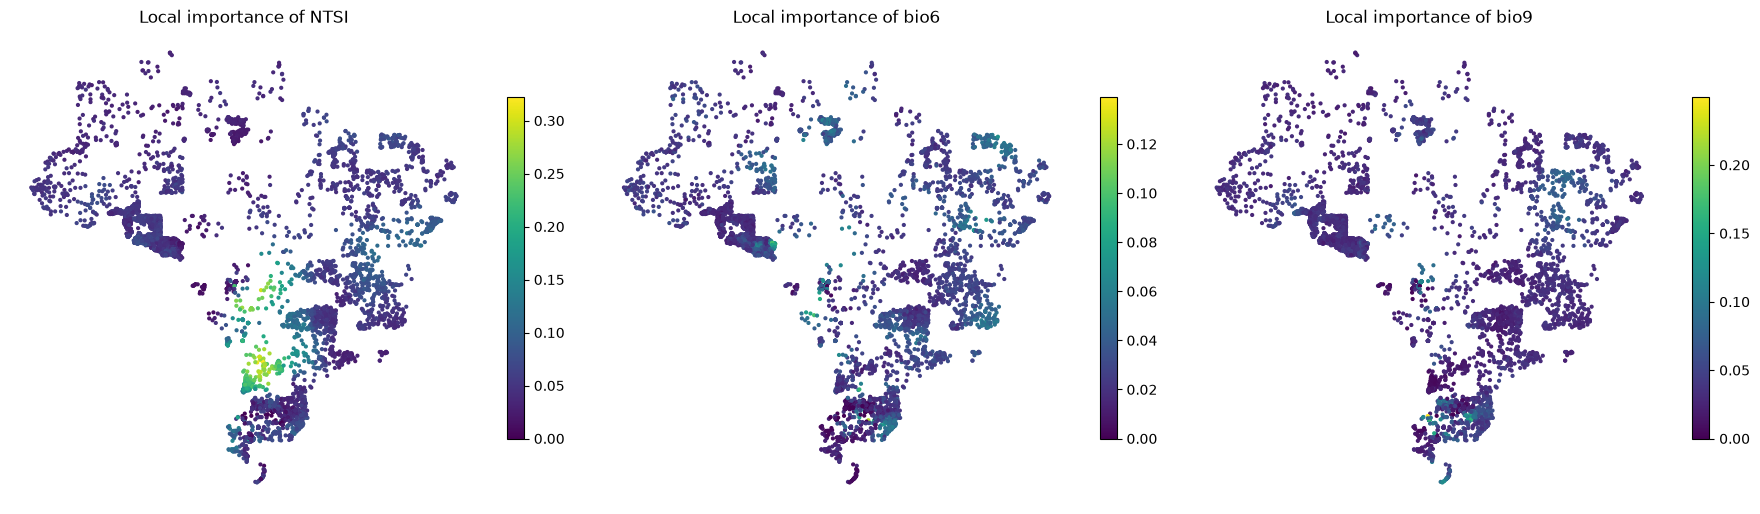

In [26]:
# Local importance of each predictor at each training sample.
local_imp = model_grf.get_local_feature_importance()
local_imp = local_imp[list(X_train.columns)].astype(float)

global_imp = pd.Series(
    model_grf.global_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_vars = list(global_imp.index[:3])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, var in zip(axes, top_vars):
    train_spatial.assign(importance=local_imp[var].to_numpy()).plot(
        ax=ax,
        column="importance",
        cmap="viridis",
        markersize=4,
        legend=True,
        legend_kwds={"shrink": 0.6}
    )
    ax.set_title(f"Local importance of {var}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## 17. Map the test predictions

Left: observed classes. Right: classes predicted by the combined GRF in the test blocks.

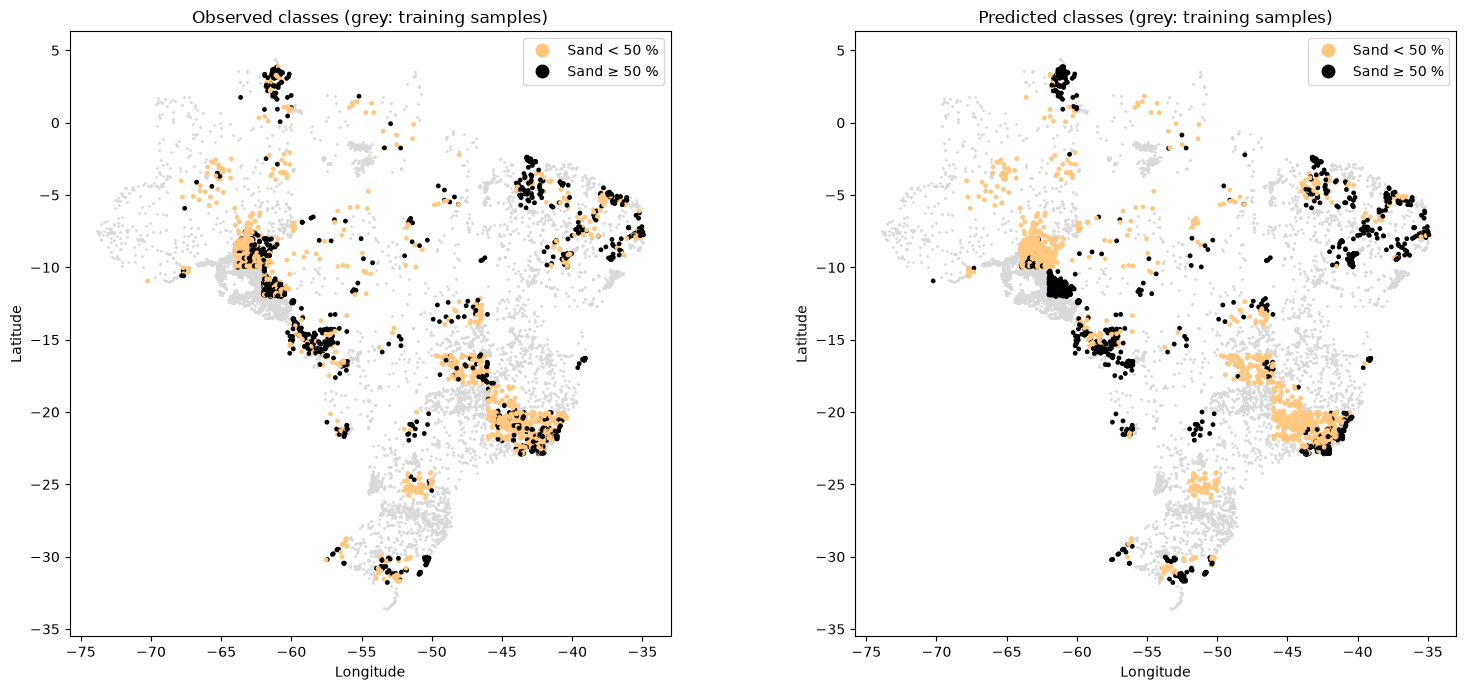

In [27]:
# Plot observed and predicted classes in the test blocks.
test_plot = test_spatial.assign(
    Observed=y_test_class.map(dict(enumerate(class_names))).to_numpy(),
    Predicted=pd.Series(pred_class["GRF (combined)"]).map(dict(enumerate(class_names))).to_numpy()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, column in zip(axes, ["Observed", "Predicted"]):
    train_spatial.plot(ax=ax, color="0.85", markersize=1)
    test_plot.plot(
        ax=ax,
        column=column,
        categorical=True,
        cmap="copper_r",
        markersize=6,
        legend=True
    )
    ax.set_title(f"{column} classes (grey: training samples)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

## 18. Final spatial-CV checks

A last consistency check: no block is shared between training and test, nor between the training and validation parts of any cross-validation fold.

In [28]:
# Check train/test block separation.
assert not (
    set(train_spatial["block_id"])
    & set(test_spatial["block_id"])
)

# Check every CV fold.
for train_idx, validation_idx in spatial_cv:
    assert not (
        set(train_spatial.loc[train_idx, "block_id"])
        & set(train_spatial.loc[validation_idx, "block_id"])
    )

print("FINAL CHECK PASSED")
print("- no block is shared between training and test")
print("- no block is shared within a CV split")

FINAL CHECK PASSED
- no block is shared between training and test
- no block is shared within a CV split


## Summary

- GRF is to Random Forest what GWR is to OLS: a **local** version that lets the relationships change in space.
- PyGRF is a regression forest; trained on 0/1 classes it predicts the **probability** of the sandy class, which is turned into a class with a 0.5 threshold.
- Compare the **Global RF**, **Local RF** and **GRF (combined)** rows on the independent spatial test: the local forests help only where the test blocks resemble nearby training regions.
- The main extra value of GRF is interpretation: the **local importance maps** show where each predictor drives the classification.

## References

- Georganos, S., et al. (2021). Geographical random forests: a spatial extension of the random forest algorithm to address spatial heterogeneity in remote sensing and population modelling. *Geocarto International*, 36(2), 121–136.
- Sun, K., Zhou, R. Z., Kim, J., & Hu, Y. (2024). PyGRF: An improved Python Geographical Random Forest model and case studies in public health and natural disasters. *Transactions in GIS*, 28(7), 2476–2491.